The dataset is imbalanced, with only ~17% of the observations belonging to the positive class (Churn=1).

This imbalance can affect model performance, particularly for algorithms sensitive to class distribution (e.g., Logistic Regression).

For tree-based models like Random Forest or LightGBM, imbalance has less impact but still needs consideration (scale_pos_weight or class_weight).

* Professional Considerations for Modeling:

Class Weighting: Adjust class_weight='balanced' in logistic regression or other linear models to compensate for minority class underrepresentation.

* Resampling Techniques:

Oversampling: SMOTE, ADASYN to synthetically generate minority class samples.

Undersampling: Reduce majority class observations to balance dataset.

Hybrid Approaches: Combination of oversampling and undersampling (e.g., SMOTE + Tomek Links).

Evaluation Metrics: Use metrics that are sensitive to class imbalance, such as Precision, Recall, F1-Score, ROC-AUC, rather than accuracy alone.

In [131]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import warnings
warnings.filterwarnings("ignore")

In [163]:
df = pd.read_csv("/content/ecommerce_customer_churn.csv")
df.head()

,Tenure,WarehouseToHome,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,DaySinceLastOrder,CashbackAmount,Churn
0,15.0,29.0,4,Laptop & Accessory,3,Single,2,0,7.0,143.32,0
1,7.0,25.0,4,Mobile,1,Married,2,0,7.0,129.29,0
2,27.0,13.0,3,Laptop & Accessory,1,Married,5,0,7.0,168.54,0
3,20.0,25.0,4,Fashion,3,Divorced,7,0,NaN,230.27,0
4,30.0,15.0,4,Others,4,Single,8,0,8.0,322.17,0


In [164]:
print(f"Dataset shape: {df.shape}\n")
print(f"Dataset columns: {df.columns}\n")
print(f"Dataset's Nulls: {df.isnull().sum()}\n")
print(f"Dataset's Duplicates: {df.duplicated().sum()}\n")
print(f"Dataset summary: {df.info()}\n")

Dataset shape: (3941, 11)

Dataset columns: Index(['Tenure', 'WarehouseToHome', 'NumberOfDeviceRegistered',
       'PreferedOrderCat', 'SatisfactionScore', 'MaritalStatus',
       'NumberOfAddress', 'Complain', 'DaySinceLastOrder', 'CashbackAmount',
       'Churn'],
      dtype='object')

Dataset's Nulls: Tenure                      194
WarehouseToHome             169
NumberOfDeviceRegistered      0
PreferedOrderCat              0
SatisfactionScore             0
MaritalStatus                 0
NumberOfAddress               0
Complain                      0
DaySinceLastOrder           213
CashbackAmount                0
Churn                         0
dtype: int64

Dataset's Duplicates: 671

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3941 entries, 0 to 3940
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Tenure                    3747 non-null   float64
 1   WarehouseToHome        

In [165]:
df.isna().mean().sort_values(ascending=False)


,0
DaySinceLastOrder,0.054047
Tenure,0.049226
WarehouseToHome,0.042883
NumberOfDeviceRegistered,0.000000
PreferedOrderCat,0.000000
MaritalStatus,0.000000
SatisfactionScore,0.000000
NumberOfAddress,0.000000
Complain,0.000000
CashbackAmount,0.000000


In [166]:
df['PreferedOrderCat'].value_counts()

,count
PreferedOrderCat,
Laptop & Accessory,1458
Mobile Phone,887
Fashion,585
Mobile,559
Grocery,273
Others,179


In [167]:
df['PreferedOrderCat'].replace('Mobile Phone', 'Mobile', inplace=True)

In [168]:
df['Churn'].value_counts(normalize=True)

,proportion
Churn,
0,0.828977
1,0.171023


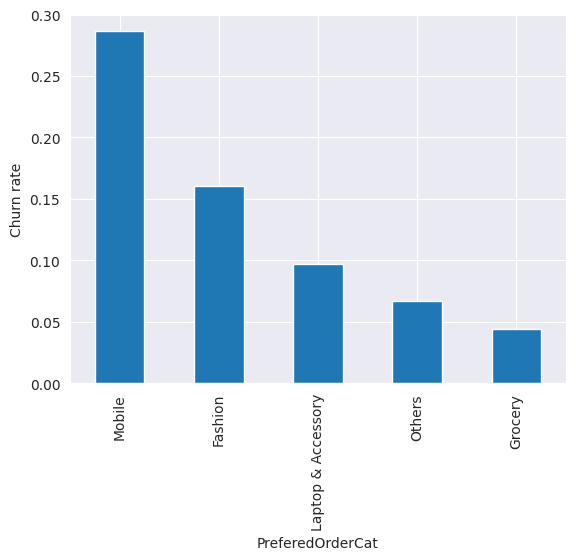

In [169]:
churn_rates = df.groupby("PreferedOrderCat")['Churn'].mean().sort_values(ascending=False)
churn_rates.plot(kind='bar')
plt.ylabel("Churn rate")
plt.show()

In [170]:

df['DaySinceLastOrder'] = df['DaySinceLastOrder'].fillna(df['DaySinceLastOrder'].max()+1)



In [171]:
missing_count = df.isna().sum()

missing_percent = (missing_count / len(df)) * 100

missing_df = pd.DataFrame({
    'MissingCount': missing_count,
    'MissingPercent': missing_percent
})

print(missing_df)

                          MissingCount  MissingPercent
Tenure                             194        4.922608
WarehouseToHome                    169        4.288252
NumberOfDeviceRegistered             0        0.000000
PreferedOrderCat                     0        0.000000
SatisfactionScore                    0        0.000000
MaritalStatus                        0        0.000000
NumberOfAddress                      0        0.000000
Complain                             0        0.000000
DaySinceLastOrder                    0        0.000000
CashbackAmount                       0        0.000000
Churn                                0        0.000000


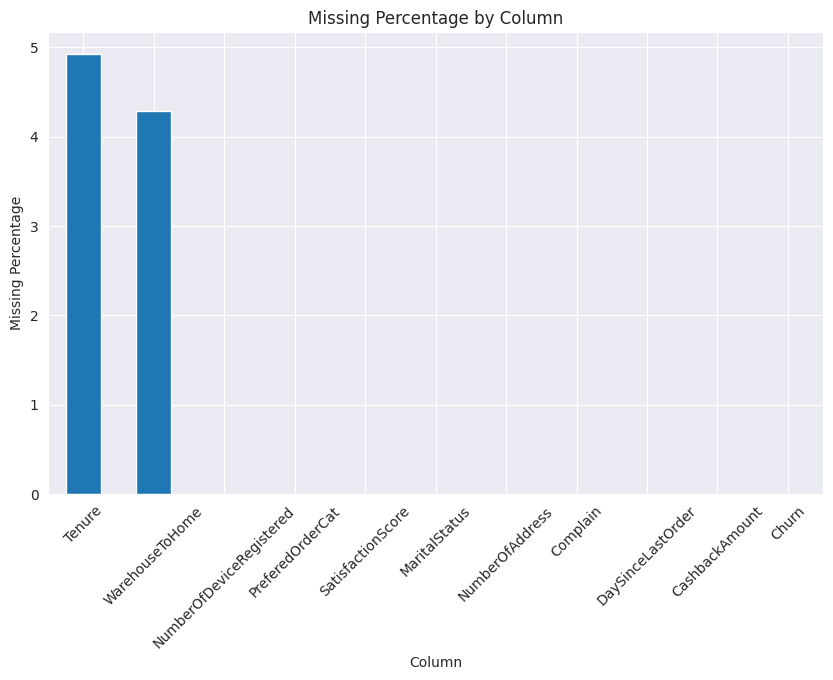

In [172]:
dt=missing_percent.sort_values(ascending=False)
plt.figure(figsize=(10, 6))
dt.plot(kind='bar')
plt.ylabel('Missing Percentage')
plt.xlabel('Column')
plt.title('Missing Percentage by Column')
plt.xticks(rotation=45)
plt.show()

Tenure: This column has 194 missing values, which represents 4.92% of its data.
WarehouseToHome: This column has 169 missing values, accounting for 4.29% of its data.

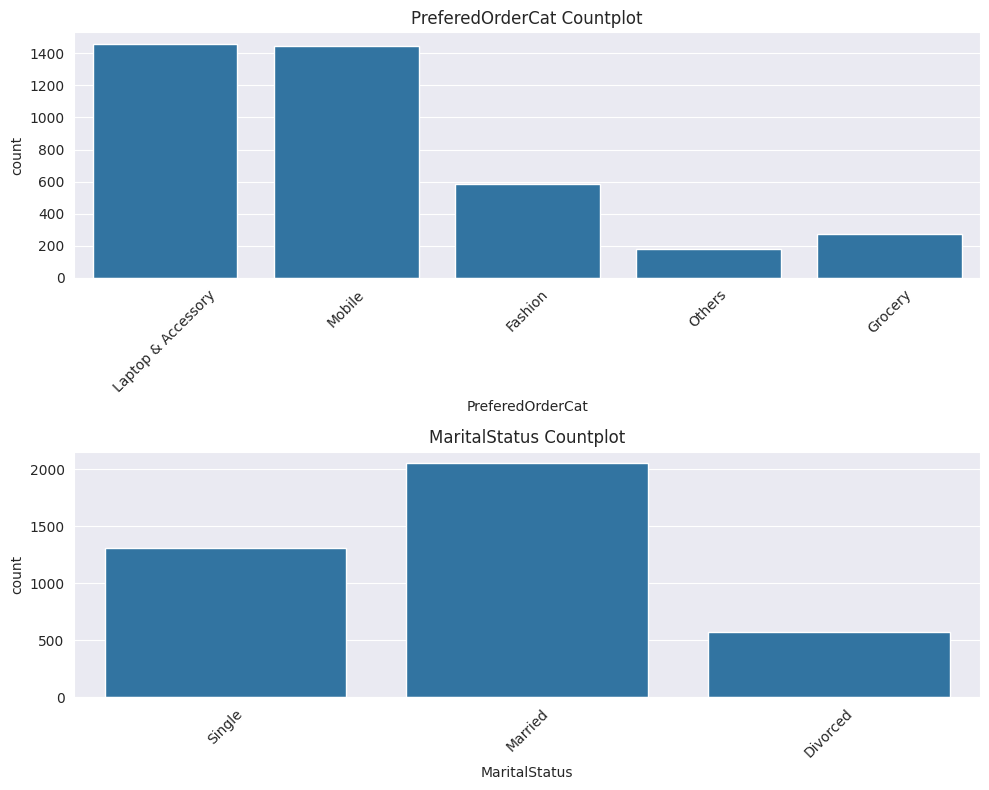

In [173]:
categorical_cols = df.select_dtypes(include=['object','category']).columns.tolist()

fig, axes = plt.subplots(len(categorical_cols), 1, figsize=(10, 4*len(categorical_cols)))
if len(categorical_cols)==1:
    axes = [axes]

for i, col in enumerate(categorical_cols):
    sns.countplot(x=col, data=df, ax=axes[i])
    axes[i].set_title(f"{col} Countplot")
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


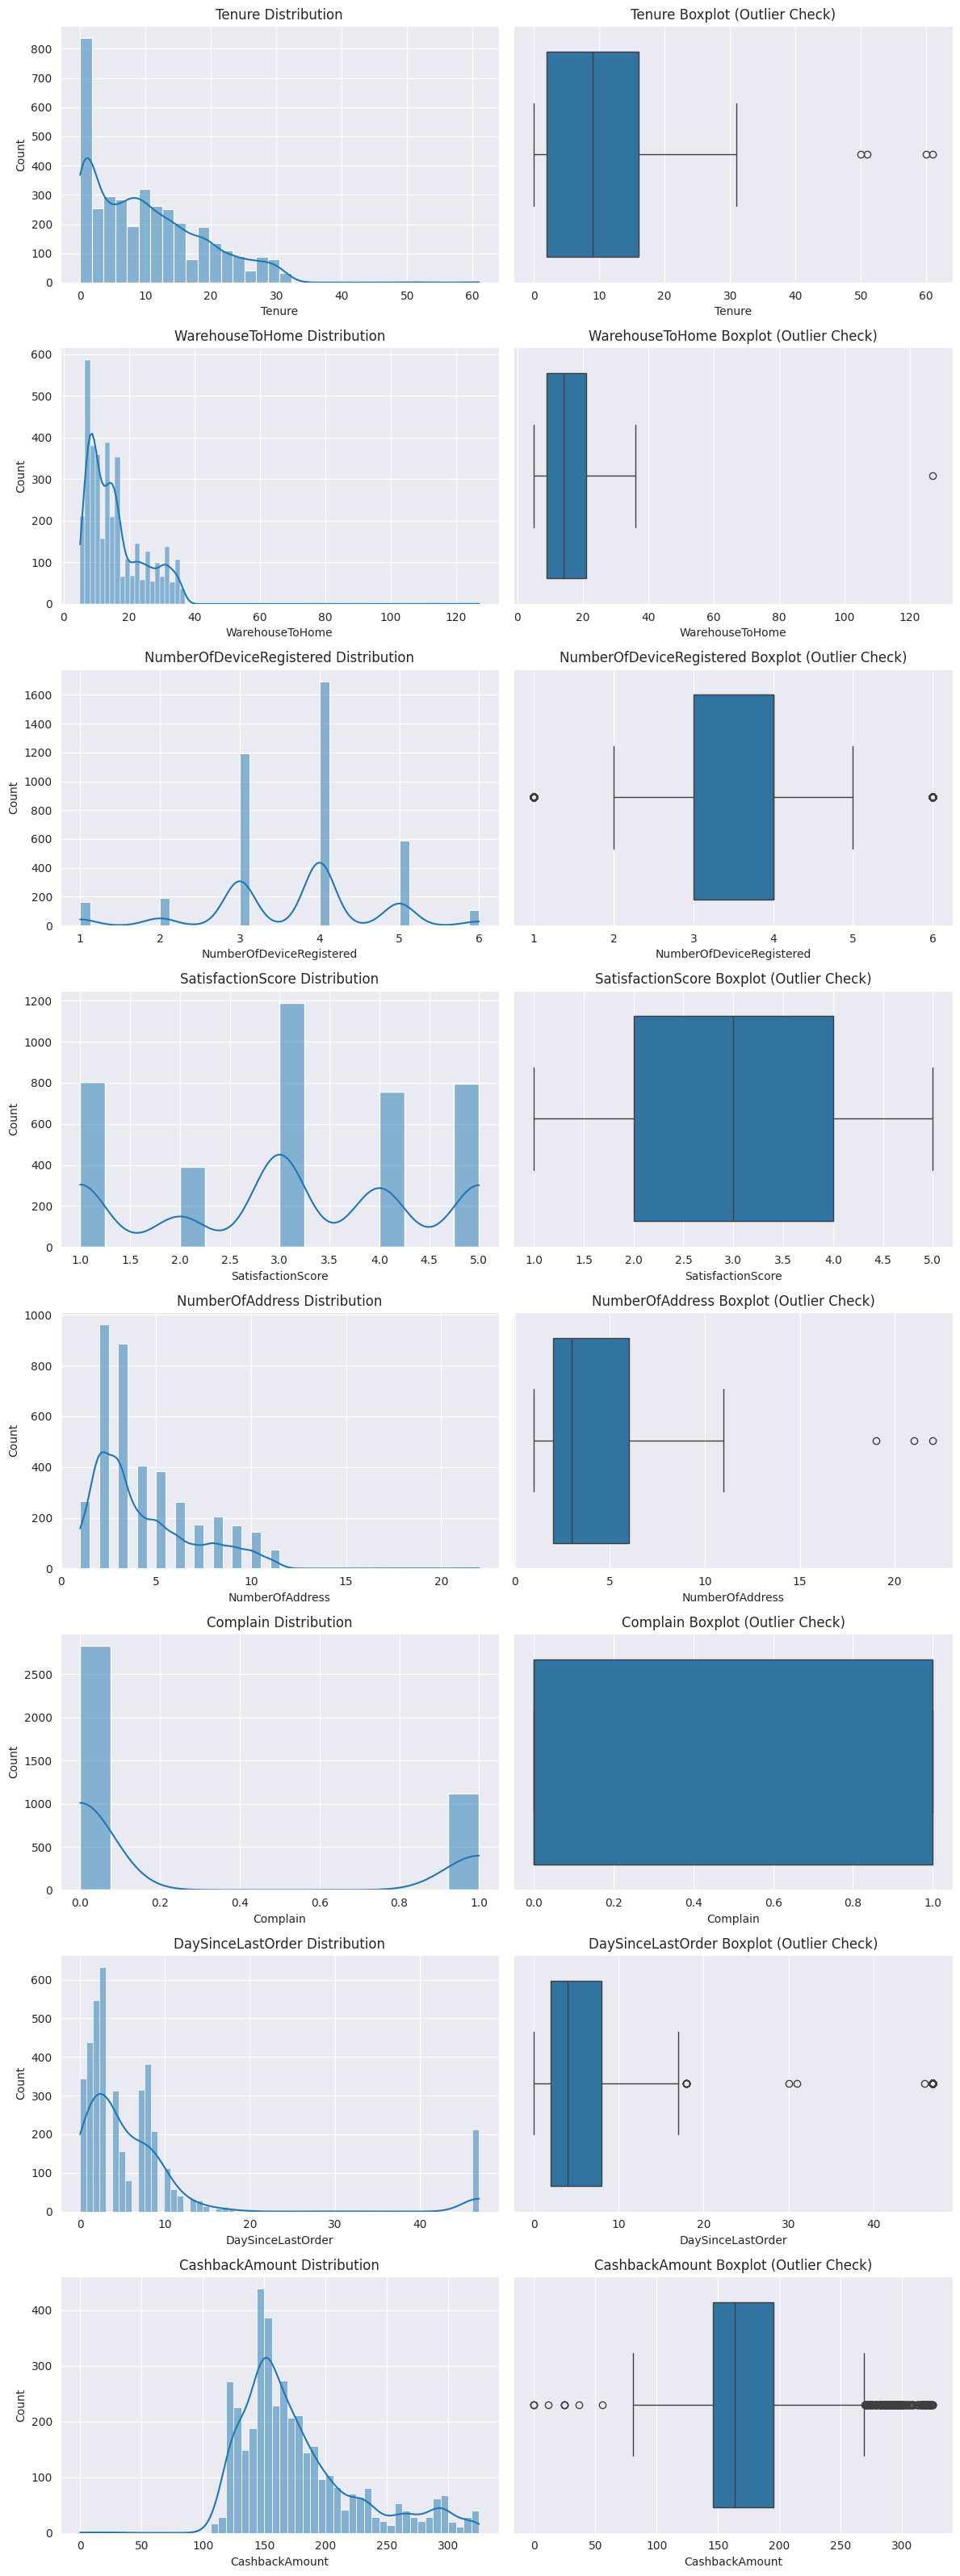

In [174]:
numeric_cols = df.select_dtypes(include=['float64','int64']).columns.tolist()
numeric_cols.remove('Churn')

fig, axes = plt.subplots(len(numeric_cols), 2, figsize=(12, 4*len(numeric_cols)))

for i, col in enumerate(numeric_cols):
    sns.histplot(df[col], kde=True, ax=axes[i,0])
    axes[i,0].set_title(f"{col} Distribution")

    sns.boxplot(x=df[col], ax=axes[i,1])
    axes[i,1].set_title(f"{col} Boxplot (Outlier Check)")

plt.tight_layout()
plt.show()


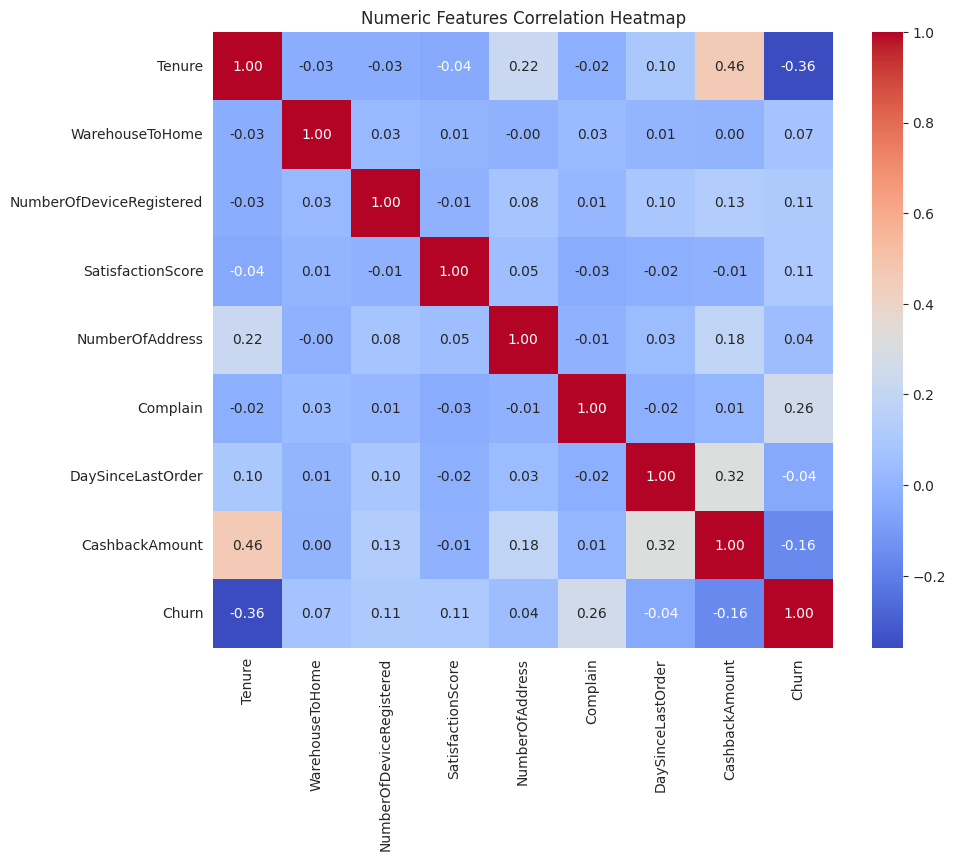

In [175]:

numeric_cols_with_target = numeric_cols + ['Churn']
plt.figure(figsize=(10,8))
sns.heatmap(df[numeric_cols_with_target].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Numeric Features Correlation Heatmap")
plt.show()


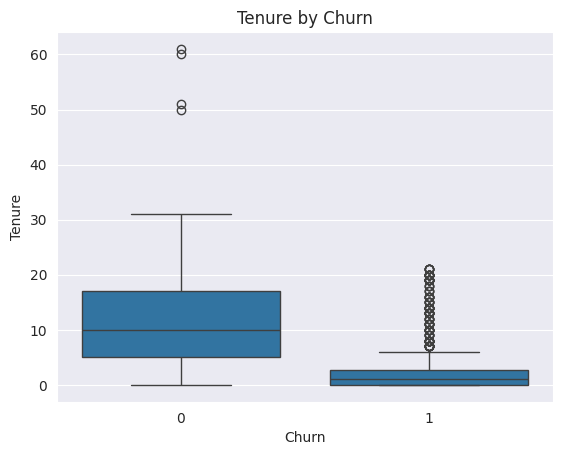

In [176]:
sns.boxplot(x="Churn", y="Tenure", data=df)
plt.title("Tenure by Churn")
plt.show()


In [177]:
outlier_summary = {}
numeric_cols = df.select_dtypes(include=['float64','int64']).columns.tolist()
numeric_cols.remove('Churn')
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    outlier_summary[col] = len(outliers)

pd.DataFrame.from_dict(outlier_summary, orient='index', columns=['NumOutliers'])


,NumOutliers
Tenure,4
WarehouseToHome,1
NumberOfDeviceRegistered,271
SatisfactionScore,0
NumberOfAddress,3
Complain,0
DaySinceLastOrder,223
CashbackAmount,316


# Based on the interquartile range (IQR) method:

* Tenure: 4 outliers
* WarehouseToHome: 1 outlier
* NumberOfDeviceRegistered: 271 outliers
* SatisfactionScore: 0 outliers
* NumberOfAddress: 3 outliers
* Complain: 0 outliers
* DaySinceLastOrder: 223 outliers
* CashbackAmount: 316 outliers

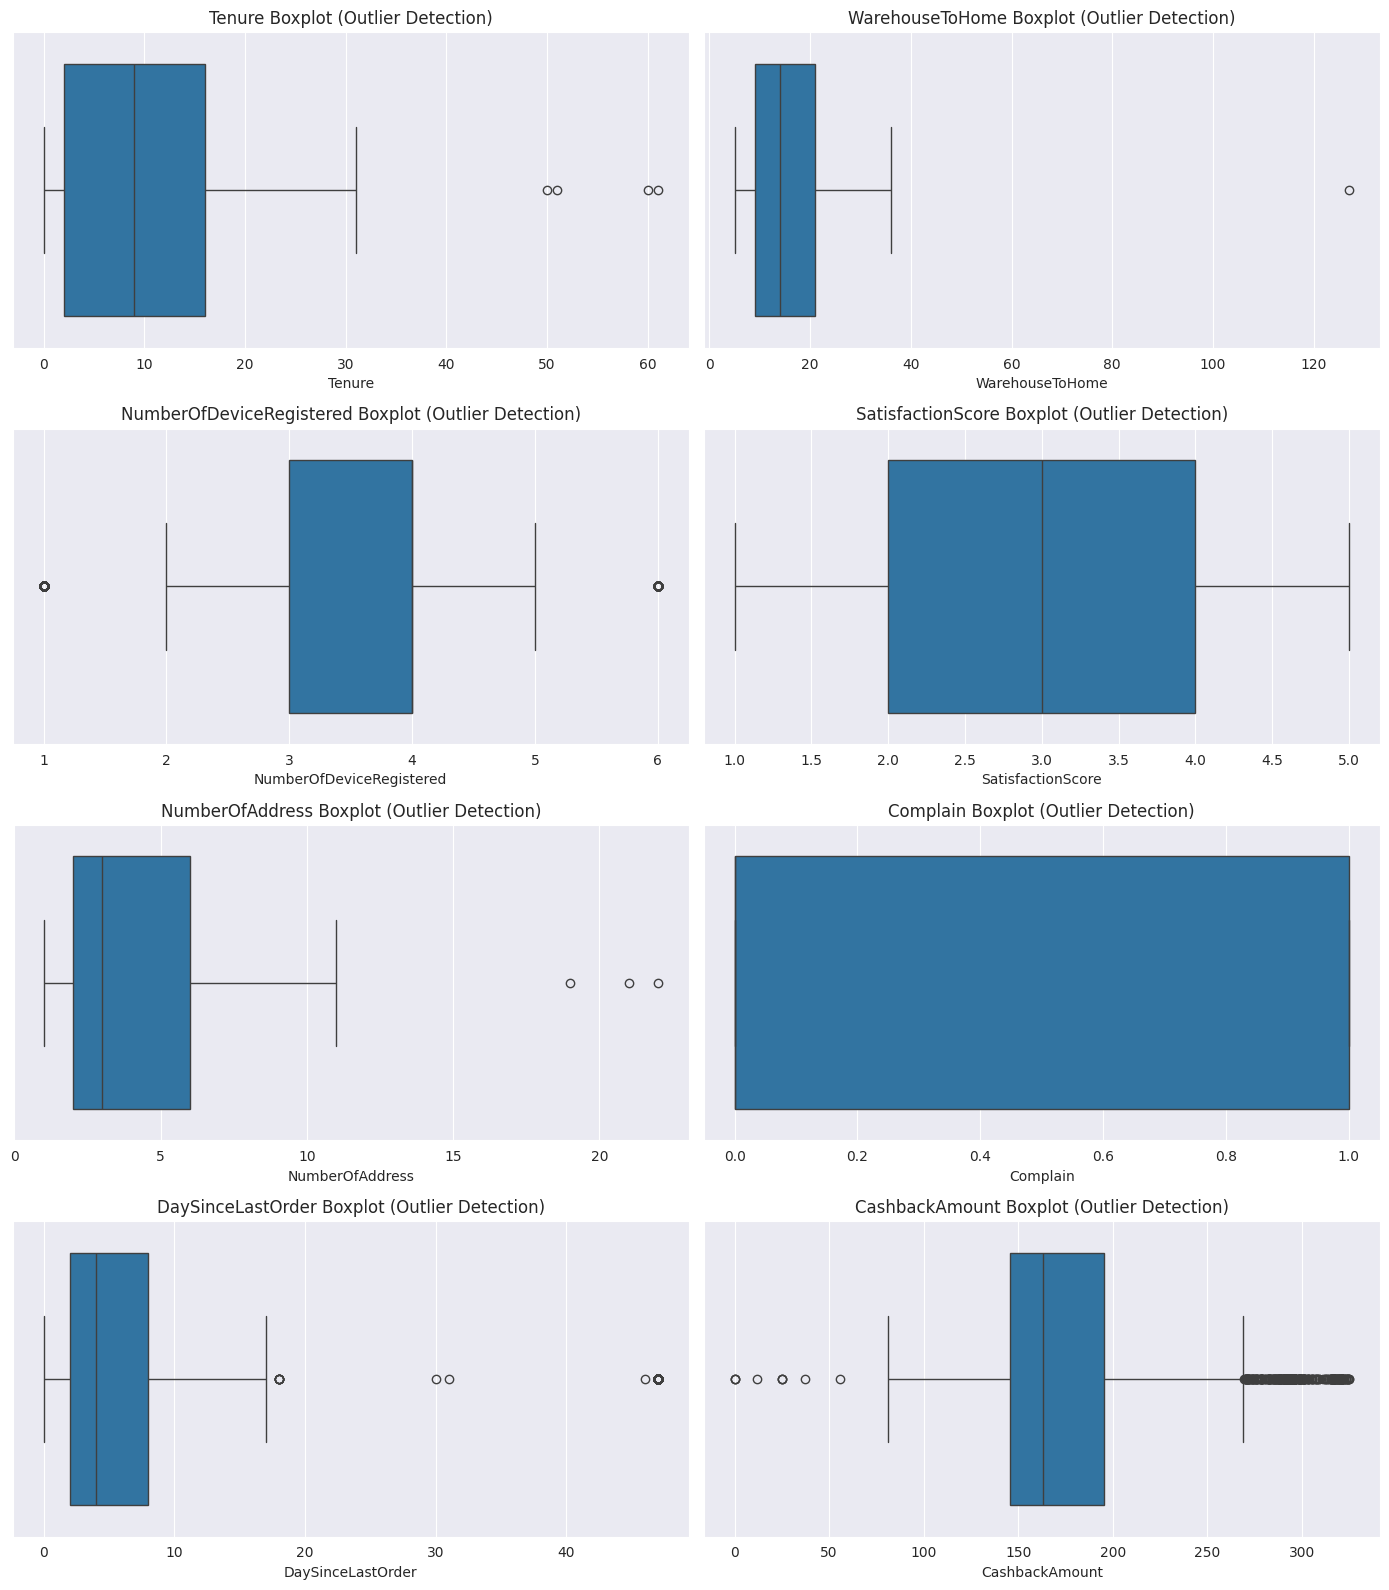

In [178]:
fig, axes = plt.subplots(4, 2, figsize=(14, 16))
axes = axes.flatten()

for i, col in enumerate(['Tenure','WarehouseToHome','NumberOfDeviceRegistered',
                         'SatisfactionScore','NumberOfAddress','Complain',
                         'DaySinceLastOrder','CashbackAmount']):
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i].set_title(f"{col} Boxplot (Outlier Detection)")

plt.tight_layout()
plt.show()


# Target Distribution & Imbalance Analysis

In [179]:
churn_counts = df['Churn'].value_counts()
churn_percent = df['Churn'].value_counts(normalize=True) * 100

print("Churn counts:\n", churn_counts)
print("\nChurn percent:\n", churn_percent)

Churn counts:
 Churn
0    3267
1     674
Name: count, dtype: int64

Churn percent:
 Churn
0    82.897742
1    17.102258
Name: proportion, dtype: float64


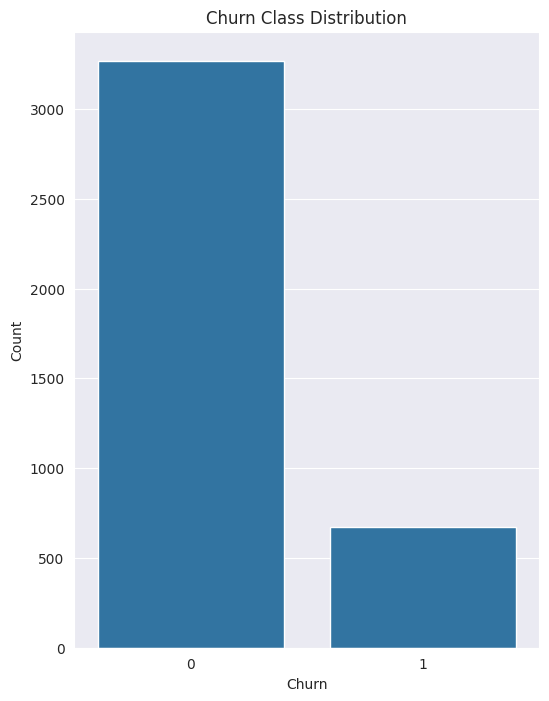

In [180]:
plt.figure(figsize=(6,8))
sns.countplot(x=df['Churn'], data=df)
plt.title("Churn Class Distribution")
plt.xlabel("Churn")
plt.ylabel("Count")
plt.show()

# Feature Engineering

In [181]:
df['Tenure'].fillna(df['Tenure'].median(), inplace=True)
df['WarehouseToHome'].fillna(df['WarehouseToHome'].median(), inplace=True)

In [182]:
df['CashbackAmount_log'] = np.log1p(df['CashbackAmount'])
df['DaySinceLastOrder_log'] = np.log1p(df['DaySinceLastOrder'])
df['NumberOfDeviceRegistered_log'] = np.log1p(df['NumberOfDeviceRegistered'])

In [183]:
df = pd.get_dummies(df, columns=['PreferedOrderCat','MaritalStatus'], drop_first=True)


In [184]:
df['DevicesPerAddress'] = df['NumberOfDeviceRegistered'] / (df['NumberOfAddress'] + 1)
df['CashbackPerTenure'] = df['CashbackAmount'] / (df['Tenure'] + 1)

DevicesPerAddress: measures device saturation per household → potential churn signal

CashbackPerTenure: normalizes cashback based on tenure → distinguishes loyal vs occasional customers

In [186]:
print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3941 entries, 0 to 3940
Data columns (total 20 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Tenure                               3941 non-null   float64
 1   WarehouseToHome                      3941 non-null   float64
 2   NumberOfDeviceRegistered             3941 non-null   int64  
 3   SatisfactionScore                    3941 non-null   int64  
 4   NumberOfAddress                      3941 non-null   int64  
 5   Complain                             3941 non-null   int64  
 6   DaySinceLastOrder                    3941 non-null   float64
 7   CashbackAmount                       3941 non-null   float64
 8   Churn                                3941 non-null   int64  
 9   CashbackAmount_log                   3941 non-null   float64
 10  DaySinceLastOrder_log                3941 non-null   float64
 11  NumberOfDeviceRegistered_log  

In [187]:
df.head()

,Tenure,WarehouseToHome,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,DaySinceLastOrder,CashbackAmount,Churn,CashbackAmount_log,DaySinceLastOrder_log,NumberOfDeviceRegistered_log,PreferedOrderCat_Grocery,PreferedOrderCat_Laptop & Accessory,PreferedOrderCat_Mobile,PreferedOrderCat_Others,MaritalStatus_Married,MaritalStatus_Single,DevicesPerAddress,CashbackPerTenure
0,15.0,29.0,4,3,2,0,7.0,143.32,0,4.972033,2.079442,1.609438,False,True,False,False,False,True,1.333333,8.957500
1,7.0,25.0,4,1,2,0,7.0,129.29,0,4.869763,2.079442,1.609438,False,False,True,False,True,False,1.333333,16.161250
2,27.0,13.0,3,1,5,0,7.0,168.54,0,5.133089,2.079442,1.386294,False,True,False,False,True,False,0.500000,6.019286
3,20.0,25.0,4,3,7,0,47.0,230.27,0,5.443586,3.871201,1.609438,False,False,False,False,False,False,0.500000,10.965238
4,30.0,15.0,4,4,8,0,8.0,322.17,0,5.778179,2.197225,1.609438,False,False,False,True,False,True,0.444444,10.392581


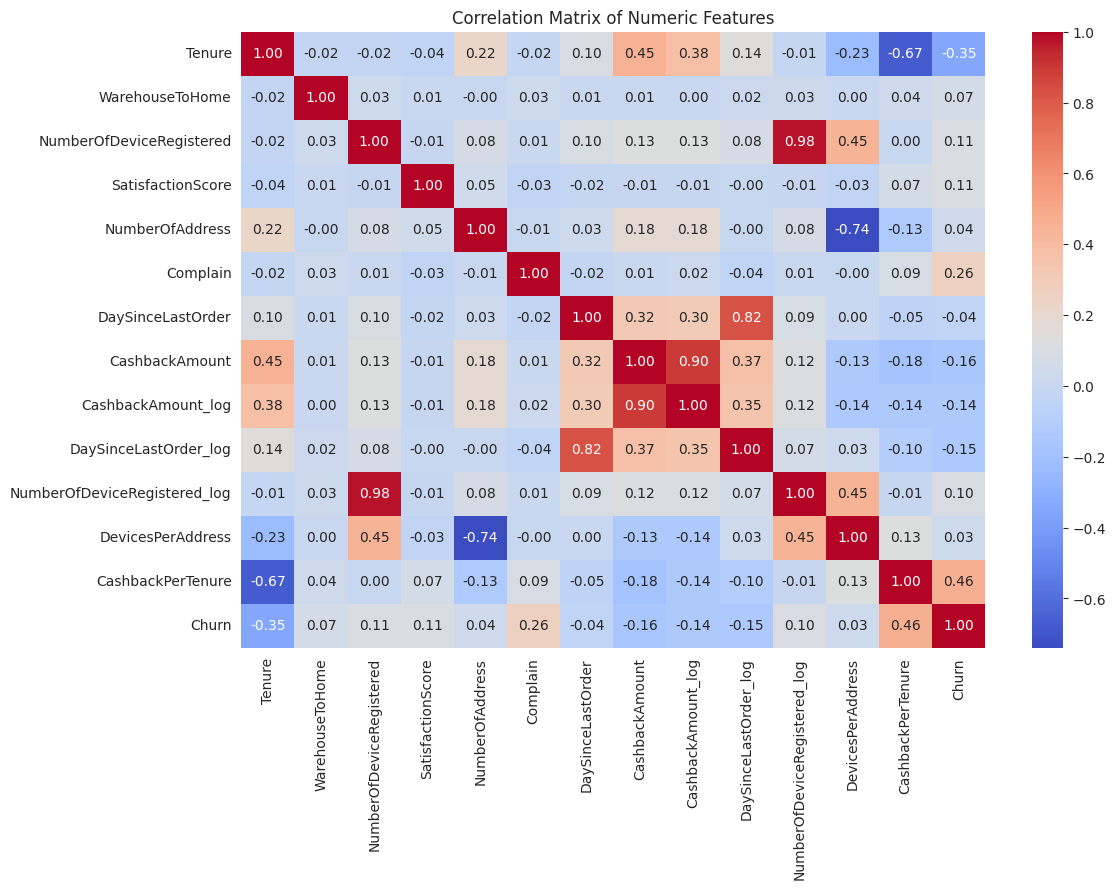

In [192]:

numeric_features = df.select_dtypes(include=['float64','int64']).columns.tolist()
numeric_features.remove('Churn')  # target excluded

# Compute correlation
corr_matrix = df[numeric_features + ['Churn']].corr()

# Plot heatmap
plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix of Numeric Features")
plt.show()


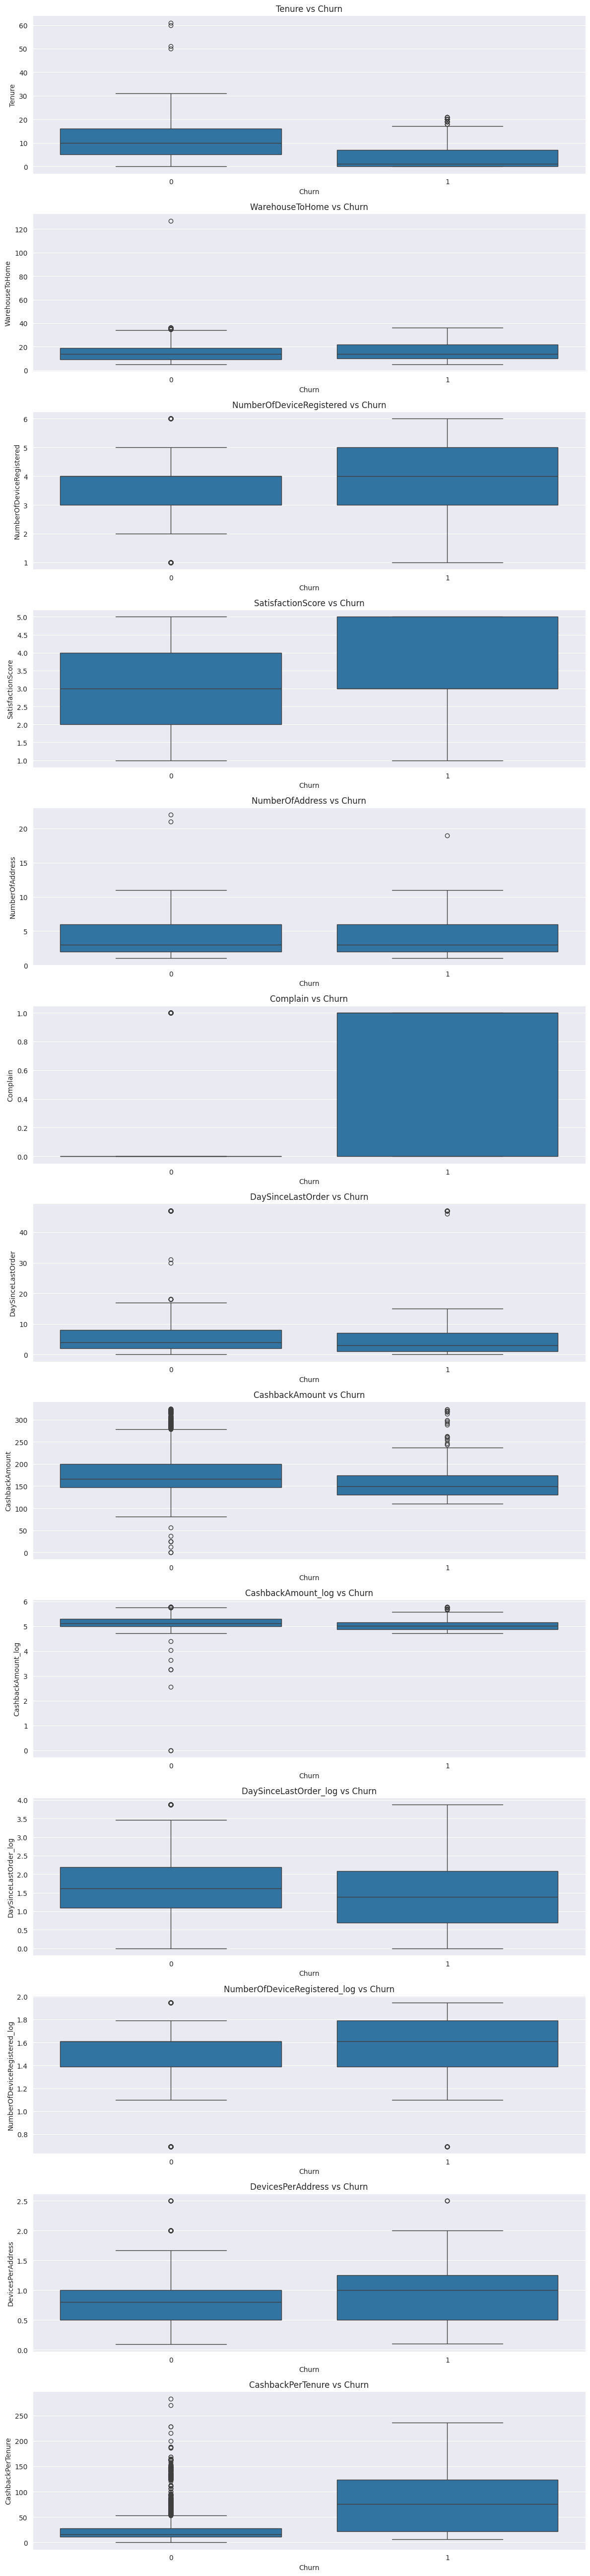

In [193]:
# Boxplot for numeric features vs Churn
fig, axes = plt.subplots(len(numeric_features), 1, figsize=(12, 4*len(numeric_features)))

for i, col in enumerate(numeric_features):
    sns.boxplot(x='Churn', y=col, data=df, ax=axes[i])
    axes[i].set_title(f"{col} vs Churn")

plt.tight_layout()
plt.show()
